In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Generalizable-DDA-RL

/content/drive/MyDrive/Generalizable-DDA-RL


### ***Import Packages***

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

from src.player import SimulatedPlayer
from src.player_estimator import PlayerSkillEstimator

print("Imports Successful!")

Imports Successful!


In [8]:
%%writefile src/environment.py

import numpy as np
import gymnasium as gym

from gymnasium import spaces
from src.player import SimulatedPlayer


class GADDAEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(
        self,
        max_steps=200,
        target_win_rate=0.70,
        player_config=None,
        seed=None
    ):

        super().__init__()

        if player_config is None:
            player_config = {
                "initial_skill": 0.5,
                "learning_rate": 0.0,
                "fatigue_rate": 0.0,
                "noise_std": 0.05
            }

        self.max_steps = max_steps
        self.target_win_rate = target_win_rate
        self.player_config = player_config
        self.seed_value = seed

        self.action_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(1,),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(5,),
            dtype=np.float32
        )

        self.player = None

        self.step_count = 0
        self.difficulty = 0.5

        self.outcome_history = []
        self.difficulty_history = []
        self.error_history = []

        self.estimated_skill = 0.5
        self.uncertainty = 0.5

        self.reset(seed=seed)


    def _create_player(self, seed=None):

        self.player = SimulatedPlayer(
            initial_skill=self.player_config["initial_skill"],
            learning_rate=self.player_config["learning_rate"],
            fatigue_rate=self.player_config["fatigue_rate"],
            noise_std=self.player_config["noise_std"],
            seed=seed
        )


    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        if seed is not None:
            self.seed_value = seed

        self._create_player(seed=self.seed_value)

        self.step_count = 0
        self.difficulty = 0.5

        self.outcome_history = []
        self.difficulty_history = [self.difficulty]
        self.error_history = []

        self.estimated_skill = float(
            self.player_config["initial_skill"]
        )

        self.uncertainty = 0.5

        observation = self._get_observation()

        return observation, {}


    def _get_recent_win_rate(self):

        if len(self.outcome_history) == 0:
            return self.target_win_rate

        window = min(
            10,
            len(self.outcome_history)
        )

        return float(
            np.mean(
                self.outcome_history[-window:]
            )
        )


    def _update_estimate(
        self,
        telemetry
    ):

        observed_skill = float(
            np.clip(
                self.difficulty
                + (
                    0.15
                    if telemetry["success"] == 1
                    else -0.15
                )
                - 0.10 * telemetry["error_rate"],
                0.0,
                1.0
            )
        )

        prediction_error = abs(
            observed_skill
            - self.estimated_skill
        )

        learning_rate = 0.15

        self.estimated_skill = float(
            np.clip(
                (
                    (1.0 - learning_rate)
                    * self.estimated_skill
                )
                +
                (
                    learning_rate
                    * observed_skill
                ),
                0.0,
                1.0
            )
        )

        if len(self.outcome_history) < 5:

            self.uncertainty = 0.5

        else:

            recent_outcomes = np.array(
                self.outcome_history[-10:]
            )

            outcome_variability = np.std(
                recent_outcomes
            )

            self.uncertainty = float(
                np.clip(
                    0.5 * prediction_error
                    +
                    0.5 * outcome_variability,
                    0.0,
                    1.0
                )
            )

        return {
            "estimated_skill":
                self.estimated_skill,

            "uncertainty":
                self.uncertainty
        }


    def _get_streak(self):

        if len(self.outcome_history) == 0:
            return 0.0

        recent = self.outcome_history

        last_outcome = recent[-1]

        streak = 0

        for outcome in reversed(recent):

            if outcome == last_outcome:
                streak += 1
            else:
                break

        signed_streak = (
            streak
            if last_outcome == 1
            else -streak
        )

        return float(
            np.clip(
                signed_streak / 10.0,
                -1.0,
                1.0
            )
        )


    def _get_observation(self):

        recent_win_rate = (
            self._get_recent_win_rate()
        )

        streak = self._get_streak()

        normalized_streak = (
            (streak + 1.0)
            / 2.0
        )

        observation = np.array(
            [
                self.estimated_skill,
                self.uncertainty,
                self.difficulty,
                recent_win_rate,
                normalized_streak
            ],
            dtype=np.float32
        )

        return np.clip(
            observation,
            0.0,
            1.0
        )


    def step(self, action):

        action = np.asarray(
            action,
            dtype=np.float32
        )

        target_difficulty = float(
            np.clip(
                action[0],
                0.0,
                1.0
            )
        )

        previous_difficulty = (
            self.difficulty
        )

        smoothing = 0.20

        self.difficulty = float(
            (
                (1.0 - smoothing)
                * self.difficulty
            )
            +
            (
                smoothing
                * target_difficulty
            )
        )

        self.difficulty = float(
            np.clip(
                self.difficulty,
                0.0,
                1.0
            )
        )

        self.difficulty_history.append(
            self.difficulty
        )

        telemetry = self.player.play(
            self.difficulty
        )

        self.outcome_history.append(
            telemetry["success"]
        )

        self.error_history.append(
            telemetry["error_rate"]
        )

        estimate = self._update_estimate(
            telemetry
        )

        recent_win_rate = (
            self._get_recent_win_rate()
        )

        win_rate_error = (
            recent_win_rate
            - self.target_win_rate
        )

        flow_penalty = (
            8.0
            * (
                win_rate_error ** 2
            )
        )

        flow_reward = (
            1.0
            - flow_penalty
        )

        if abs(win_rate_error) <= 0.05:

            flow_zone_bonus = 0.50

        else:

            flow_zone_bonus = 0.0

        difficulty_change = abs(
            self.difficulty
            - previous_difficulty
        )

        smoothness_penalty = (
            0.20
            * difficulty_change
        )

        error_penalty = (
            0.10
            * telemetry["error_rate"]
        )

        uncertainty_penalty = (
            0.05
            * estimate["uncertainty"]
        )

        reward = float(
            flow_reward
            +
            flow_zone_bonus
            -
            smoothness_penalty
            -
            error_penalty
            -
            uncertainty_penalty
        )

        self.step_count += 1

        terminated = (
            self.step_count
            >= self.max_steps
        )

        truncated = False

        observation = (
            self._get_observation()
        )

        info = {
            "difficulty":
                float(self.difficulty),

            "target_difficulty":
                float(target_difficulty),

            "true_skill":
                float(
                    telemetry["true_skill"]
                ),

            "estimated_skill":
                float(
                    estimate[
                        "estimated_skill"
                    ]
                ),

            "uncertainty":
                float(
                    estimate[
                        "uncertainty"
                    ]
                ),

            "success":
                int(
                    telemetry["success"]
                ),

            "recent_win_rate":
                float(
                    recent_win_rate
                ),

            "error_rate":
                float(
                    telemetry["error_rate"]
                ),

            "completion_time":
                float(
                    telemetry["completion_time"]
                ),

            "success_probability":
                float(
                    telemetry[
                        "success_probability"
                    ]
                )
        }

        return (
            observation,
            reward,
            terminated,
            truncated,
            info
        )

Overwriting src/environment.py


In [9]:
from src.environment import GADDAEnv

test_env = GADDAEnv(
    max_steps=200,
    target_win_rate=0.70,
    player_config={
        "initial_skill": 0.5,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },
    seed=42
)

obs, info = test_env.reset(seed=42)

print("Updated environment loaded successfully!")
print("Observation:", obs)

Updated environment loaded successfully!
Observation: [0.5 0.5 0.5 0.7 0.5]


### ***Import and Create Environment***

In [10]:
from src.environment import GADDAEnv


env = GADDAEnv(
    max_steps=200,
    target_win_rate=0.70,
    player_config={
        "initial_skill": 0.5,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },
    seed=42
)


print("Environment Created Successfully")
print(
    "\nObservation space :",
    env.observation_space
)

print(
    "Action space      :",
    env.action_space
)

Environment Created Successfully

Observation space : Box(0.0, 1.0, (5,), float32)
Action space      : Box(0.0, 1.0, (1,), float32)


### ***Reset the Environment***

In [11]:
observation, info = env.reset(
    seed=42
)

print(
    "Initial observation:",
    observation
)

print(
    "Initial info:",
    info
)

Initial observation: [0.5 0.5 0.5 0.7 0.5]
Initial info: {}


### ***Testing Random Actions***

In [12]:
observation, info = env.reset(
    seed=42
)

total_reward = 0


for step in range(10):

    action = (
        env.action_space.sample()
    )

    (
        observation,
        reward,
        terminated,
        truncated,
        info
    ) = env.step(
        action
    )


    total_reward += reward


    print(
        f"\nStep {step + 1}"
    )

    print(
        "Action / Difficulty:",
        action
    )

    print(
        "Observation:",
        observation
    )

    print(
        "Reward:",
        round(
            reward,
            4
        )
    )

    print(
        "Win Rate:",
        round(
            info[
                "recent_win_rate"
            ],
            3
        )
    )


    if (
        terminated
        or
        truncated
    ):

        break


print(
    "\nTotal Reward:",
    round(
        total_reward,
        4
    )
)


Step 1
Action / Difficulty: [0.78470874]
Observation: [0.48518714 0.5        0.55694175 0.         0.45      ]
Reward: -2.9621
Win Rate: 0.0

Step 2
Action / Difficulty: [0.03929915]
Observation: [0.45792106 0.5        0.45341322 0.         0.4       ]
Reward: -2.9657
Win Rate: 0.0

Step 3
Action / Difficulty: [0.04484674]
Observation: [0.42148584 0.5        0.37169993 0.         0.35      ]
Reward: -2.968
Win Rate: 0.0

Step 4
Action / Difficulty: [0.39371824]
Observation: [0.3921785  0.5        0.37610358 0.         0.3       ]
Reward: -2.9459
Win Rate: 0.0

Step 5
Action / Difficulty: [0.6216095]
Observation: [0.41963243 0.29151314 0.42520478 0.2        0.55      ]
Reward: -1.0244
Win Rate: 0.2

Step 6
Action / Difficulty: [0.02373832]
Observation: [0.38592428 0.29869947 0.3449115  0.16666667 0.45      ]
Reward: -1.3065
Win Rate: 0.167

Step 7
Action / Difficulty: [0.71491134]
Observation: [0.36837238 0.23346998 0.41891146 0.14285715 0.4       ]
Reward: -1.5097
Win Rate: 0.143

Ste

### ***Running Complete Random Episode***

In [13]:
env = GADDAEnv(
    max_steps=200,
    target_win_rate=0.70,
    player_config={
        "initial_skill": 0.5,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },
    seed=42
)


observation, info = env.reset(
    seed=42
)


episode_reward = 0


difficulty_history = []

win_rate_history = []

true_skill_history = []

estimated_skill_history = []


terminated = False


while not terminated:

    action = (
        env.action_space.sample()
    )


    (
        observation,
        reward,
        terminated,
        truncated,
        info
    ) = env.step(
        action
    )


    episode_reward += reward


    difficulty_history.append(
        info["difficulty"]
    )

    win_rate_history.append(
        info[
            "recent_win_rate"
        ]
    )

    true_skill_history.append(
        info[
            "true_skill"
        ]
    )

    estimated_skill_history.append(
        info[
            "estimated_skill"
        ]
    )


print(
    "Episode Completed :)\n"
)

print(
    "Total Episode Reward :",
    round(
        episode_reward,
        3
    )
)

Episode Completed :)

Total Episode Reward : 45.9


### ***Random Baseline Plots***

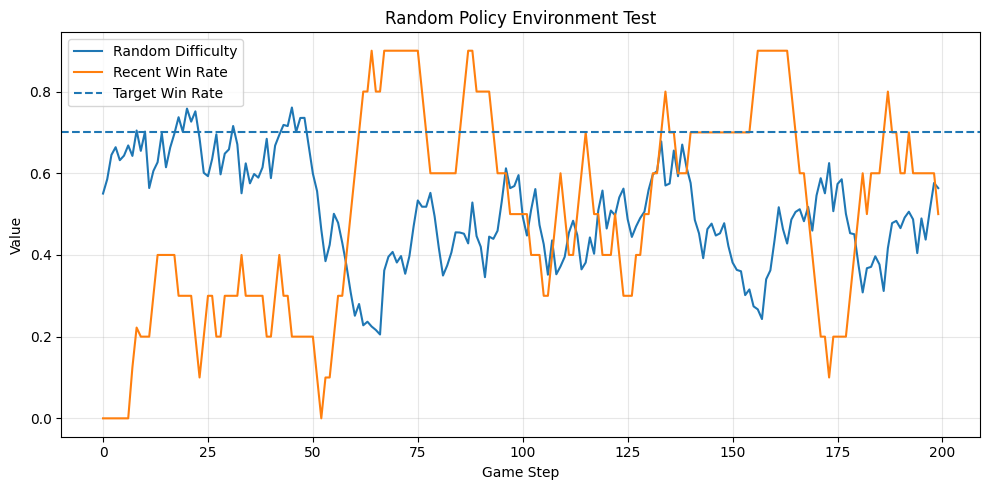

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    difficulty_history,
    label="Random Difficulty"
)

plt.plot(
    win_rate_history,
    label="Recent Win Rate"
)

plt.axhline(
    0.70,
    linestyle="--",
    label="Target Win Rate"
)

plt.xlabel("Game Step")

plt.ylabel("Value")

plt.title(
    "Random Policy Environment Test"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### ***Official Gymnasium Environment Test***

In [15]:
from gymnasium.utils.env_checker import check_env


env = GADDAEnv(
    max_steps=200,
    target_win_rate=0.70,
    seed=42
)


check_env(
    env,
    skip_render_check=True
)


print(
    "Environment Check Passed Successfully!"
)

Environment Check Passed Successfully!


In [16]:
!find src results/figures -type f | sort

results/figures/player_profiles.png
results/figures/skill_estimation_with_uncertainty.png
results/figures/true_vs_estimated_skill.png
src/baselines.py
src/environment.py
src/__init__.py
src/player_estimator.py
src/player.py
src/__pycache__/baselines.cpython-313.pyc
src/__pycache__/environment.cpython-313.pyc
src/__pycache__/__init__.cpython-313.pyc
src/__pycache__/player.cpython-313.pyc
src/__pycache__/player_estimator.cpython-313.pyc


### ***Reward Sanity Test***

In [17]:
import numpy as np
import pandas as pd

from src.environment import GADDAEnv


def evaluate_fixed_difficulty(
    difficulty,
    seed=42
):

    env = GADDAEnv(
        max_steps=200,
        target_win_rate=0.70,
        player_config={
            "initial_skill": 0.5,
            "learning_rate": 0.0,
            "fatigue_rate": 0.0,
            "noise_std": 0.05
        },
        seed=seed
    )

    obs, info = env.reset(
        seed=seed
    )

    total_reward = 0

    rewards = []

    win_rates = []

    terminated = False

    truncated = False


    while not (
        terminated
        or
        truncated
    ):

        action = np.array(
            [difficulty],
            dtype=np.float32
        )

        (
            obs,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(
            action
        )

        total_reward += reward

        rewards.append(
            reward
        )

        win_rates.append(
            info[
                "recent_win_rate"
            ]
        )


    return {

        "Difficulty":
            difficulty,

        "Total Reward":
            total_reward,

        "Mean Reward":
            np.mean(
                rewards
            ),

        "Final Win Rate":
            win_rates[-1],

        "Mean Win Rate":
            np.mean(
                win_rates
            )
    }


results = []

for difficulty in [

    0.0,
    0.2,
    0.4,
    0.5,
    0.6,
    0.8,
    1.0

]:

    results.append(

        evaluate_fixed_difficulty(
            difficulty
        )

    )


reward_test_results = pd.DataFrame(
    results
)

reward_test_results

,Difficulty,Total Reward,Mean Reward,Final Win Rate,Mean Win Rate
0,0.0,61.836409,0.309182,0.9,0.991355
1,0.2,120.366382,0.601832,0.9,0.910627
2,0.4,193.590999,0.967955,0.6,0.706109
3,0.5,107.104978,0.535525,0.4,0.499109
4,0.6,-78.852068,-0.394260,0.2,0.317381
5,0.8,-479.477651,-2.397388,0.1,0.058056
6,1.0,-567.964384,-2.839822,0.1,0.013000
